# Přednáška 3: Simulování náhodných veličin — praktický doprovod

Doplňkový notebook k `P03_simulovani.tex` (KMA/MSM). Postupně si na
vlastní pěst implementujeme a odzkoušíme každou metodu z přednášky —
od generování pseudonáhodných čísel přes metodu inverzní transformace
a zamítací metodu až po generování náhodných vektorů.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams["figure.figsize"] = (5, 4)


## 1. Generování pseudonáhodných čísel z rovnoměrného rozdělení

### 1a) Lineární kongruentní generátor (LCG)

$$x_i = (a\, x_{i-1} + c) \bmod m$$

Implementujeme ručně a podíváme se, jak (ne)náhodně to vypadá pro
"špatnou" volbu parametrů — klasický učebnicový příklad špatné mřížkové
struktury.

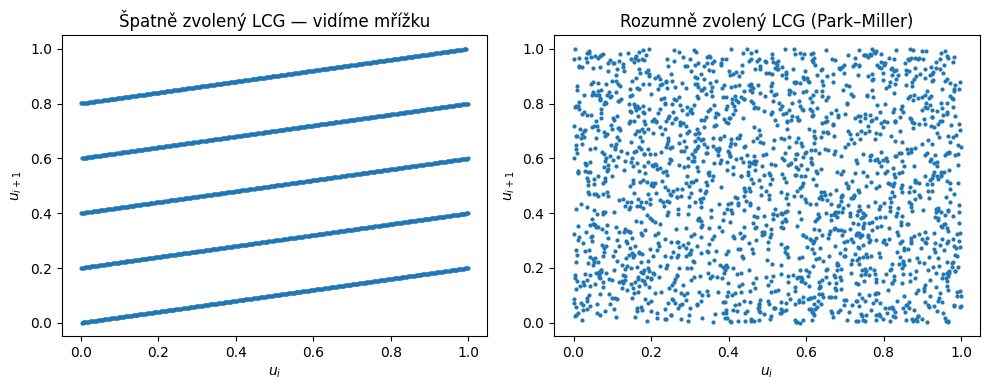

In [2]:
def lcg(seed, a, c, m, n):
    x = seed
    out = []
    for _ in range(n):
        x = (a * x + c) % m
        out.append(x / m)
    return np.array(out)

# "špatný" generátor — malá perioda, viditelná mřížková struktura
bad = lcg(seed=1, a=1229, c=1, m=2048, n=2000)

# rozumně zvolený generátor (typu minimal standard, Park-Miller)
good = lcg(seed=1, a=48271, c=0, m=2**31 - 1, n=2000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(bad[:-1], bad[1:], s=4)
axes[0].set_title("Špatně zvolený LCG — vidíme mřížku")
axes[0].set_xlabel("$u_i$"); axes[0].set_ylabel("$u_{i+1}$")

axes[1].scatter(good[:-1], good[1:], s=4)
axes[1].set_title("Rozumně zvolený LCG (Park–Miller)")
axes[1].set_xlabel("$u_i$"); axes[1].set_ylabel("$u_{i+1}$")
plt.tight_layout()
plt.show()


### 1b) Multiplikativní rekurzivní generátor

$$x_i = (a_1 x_{i-1} + \cdots + a_k x_{i-k}) \bmod m$$

Zobecnění LCG na více zpožděných členů — implementace pro obecné $k$.

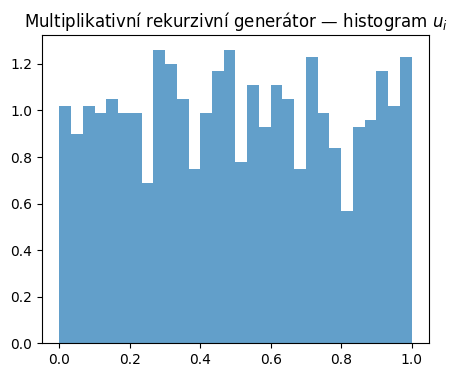

In [3]:
def multiplicative_recursive(seeds, coeffs, m, n):
    """seeds, coeffs: pole délky k (nejstarší člen jako první)."""
    k = len(seeds)
    hist = list(seeds)
    out = []
    for i in range(n):
        x_new = sum(c * hist[-j - 1] for j, c in enumerate(reversed(coeffs))) % m
        hist.append(x_new)
        out.append(x_new / m)
    return np.array(out)

mr = multiplicative_recursive(seeds=[1, 2, 3], coeffs=[65, 0, -63], m=2**31 - 1, n=1000)
plt.hist(mr, bins=30, density=True, alpha=0.7)
plt.title("Multiplikativní rekurzivní generátor — histogram $u_i$")
plt.show()


### 1c) Kombinovaný generátor (příklad z přednášky)

$$x_i=(1403580\, x_{i-2}-810728\, x_{i-3})\bmod m_1,\quad m_1=2^{32}-209$$
$$y_i=(527612\, y_{i-2}-1370589\, y_{i-3})\bmod m_2,\quad m_2=2^{32}-22853$$
$$u_i=\begin{cases}\dfrac{x_i-y_i+m_1}{m_1+1} & x_i\leq y_i\\[1ex] \dfrac{x_i-y_i}{m_1+1} & x_i> y_i\end{cases}$$

Přesně podle vzorce z přednášky.

min, max, mean: 0.00018443889877835544 0.9995421103445717 0.5082366263421294


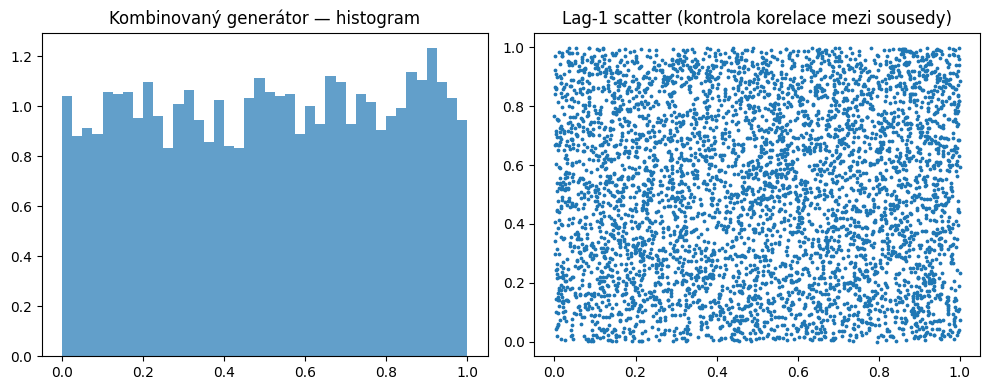

In [4]:
def combined_generator(n, seed=(12345, 67890, 11111)):
    m1 = 2**32 - 209
    m2 = 2**32 - 22853

    x_hist = list(seed)
    y_hist = list(seed)
    u = []
    for i in range(n):
        x_new = (1403580 * x_hist[-2] - 810728 * x_hist[-3]) % m1
        y_new = (527612  * y_hist[-2] - 1370589 * y_hist[-3]) % m2
        x_hist.append(x_new)
        y_hist.append(y_new)

        if x_new <= y_new:
            u_i = (x_new - y_new + m1) / (m1 + 1)
        else:
            u_i = (x_new - y_new) / (m1 + 1)
        u.append(u_i)
    return np.array(u)

combo = combined_generator(5000)
print("min, max, mean:", combo.min(), combo.max(), combo.mean())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(combo, bins=40, density=True, alpha=0.7)
axes[0].set_title("Kombinovaný generátor — histogram")
axes[1].scatter(combo[:-1], combo[1:], s=3)
axes[1].set_title("Lag-1 scatter (kontrola korelace mezi sousedy)")
plt.tight_layout()
plt.show()


### Kvalita generátoru — jednoduchý test

Přednáška zmiňuje, že kvalitu pseudonáhodných generátorů testuje řada
testů. Tady jen orientačně: $\chi^2$ test rovnoměrnosti a test na
autokorelaci.

In [5]:
# chí-kvadrát test rovnoměrnosti na kombinovaném generátoru
observed, edges = np.histogram(combo, bins=20)
expected = len(combo) / 20
chi2_stat = np.sum((observed - expected)**2 / expected)
p_value = 1 - stats.chi2.cdf(chi2_stat, df=19)
print(f"chi2 test rovnoměrnosti: statistika={chi2_stat:.2f}, p-hodnota={p_value:.3f}")

# autokorelace prvního řádu
autocorr = np.corrcoef(combo[:-1], combo[1:])[0, 1]
print(f"Autokorelace lag-1: {autocorr:.4f} (mělo by být blízko 0)")


chi2 test rovnoměrnosti: statistika=29.31, p-hodnota=0.061
Autokorelace lag-1: 0.0079 (mělo by být blízko 0)


## 2. Metoda inverzní transformace

$$X = F^{-1}(U), \quad U \sim R(0,1)$$

Ukázka na exponenciálním rozdělení, kde $F^{-1}$ známe explicitně:
$F(x) = 1-e^{-\lambda x} \Rightarrow F^{-1}(u) = -\frac{1}{\lambda}\ln(1-u)$.

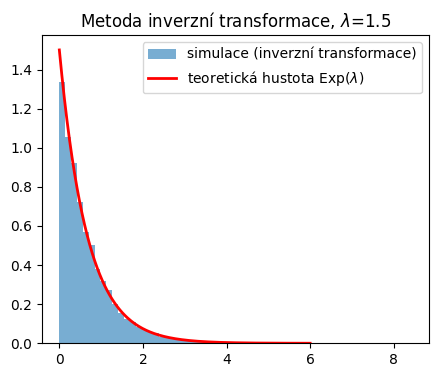

Odhad E(X) = 0.6699, teoretická 1/lambda = 0.6667


In [6]:
def inverse_transform_exponential(lam, n, rng):
    u = rng.uniform(0, 1, n)
    x = -1/lam * np.log(1 - u)
    return x

rng = np.random.default_rng(0)
lam = 1.5
sample = inverse_transform_exponential(lam, 20000, rng)

xs = np.linspace(0, 6, 200)
plt.hist(sample, bins=60, density=True, alpha=0.6, label="simulace (inverzní transformace)")
plt.plot(xs, stats.expon(scale=1/lam).pdf(xs), 'r-', lw=2, label=r"teoretická hustota Exp($\lambda$)")
plt.legend()
plt.title(rf"Metoda inverzní transformace, $\lambda$={lam}")
plt.show()

print(f"Odhad E(X) = {sample.mean():.4f}, teoretická 1/lambda = {1/lam:.4f}")


## 3. Zamítací metoda (obecná)

Máme cílovou hustotu $f(x)$, dominující hustotu $g(x)$ a konstantu $c\geq 1$
takovou, že $f(x)\leq c\cdot g(x)$ všude. Postup:
1. vygeneruj $x_i \sim g$
2. vygeneruj $v_i \sim R(0,1)$
3. spočti $T_i = c\cdot g(x_i)/f(x_i)$
4. přijmi $x_i$, pokud $v_i \cdot T_i \leq 1$

Cíl: generovat z hustoty $f(x) \propto \sin^2(\pi x)\cdot x(1-x)$ na $(0,1)$
(nestandardní tvar bez známé inverzní $F^{-1}$), dominující hustota $g$ =
rovnoměrné rozdělení na $(0,1)$.

Přijato 5000 z 11455 pokusů, míra přijetí ≈ 43.65%


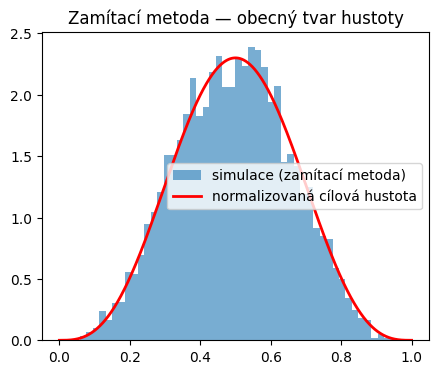

In [7]:
def f_target(x):
    return np.sin(np.pi * x)**2 * x * (1 - x)

# najdeme (numericky) maximum f na (0,1), aby platilo f <= c*g s g=1 (rovnomerne)
xs = np.linspace(0, 1, 10000)
M = f_target(xs).max()
c_const = M  # protože g(x) = 1 na (0,1), stačí c = max(f)

def rejection_sampling(f, c, n, rng):
    accepted = []
    trials = 0
    while len(accepted) < n:
        x_i = rng.uniform(0, 1)
        v_i = rng.uniform(0, 1)
        trials += 1
        T_i = c * 1.0 / f(x_i) if f(x_i) > 0 else np.inf
        if v_i * T_i <= 1:
            accepted.append(x_i)
    return np.array(accepted), trials

rng = np.random.default_rng(1)
sample_rej, trials = rejection_sampling(f_target, c_const, 5000, rng)
print(f"Přijato {len(sample_rej)} z {trials} pokusů, míra přijetí ≈ {len(sample_rej)/trials:.2%}")

norm_const = np.trapezoid(f_target(xs), xs)
plt.hist(sample_rej, bins=50, density=True, alpha=0.6, label="simulace (zamítací metoda)")
plt.plot(xs, f_target(xs)/norm_const, 'r-', lw=2, label="normalizovaná cílová hustota")
plt.legend()
plt.title("Zamítací metoda — obecný tvar hustoty")
plt.show()


## 4. Zamítací metoda pro hustotu s omezeným nosičem

Zjednodušená verze, když $f$ je nenulová jen na konečném intervalu $(a,b)$
a $M=\max_{a\le x\le b} f(x)$:
1. vygeneruj $u_i,v_i$ nezávisle z $R(0,1)$
2. $x_i = a+(b-a)u_i$
3. přijmi, pokud $v_i\cdot M \leq f(x_i)$

Použijeme trojúhelníkovou hustotu na $(0,2)$ jako ukázkový příklad.

Míra přijetí ≈ 50.03%  (očekáváme obsah trojúhelníku / obsah obdélníku = 1/2 = 50%)


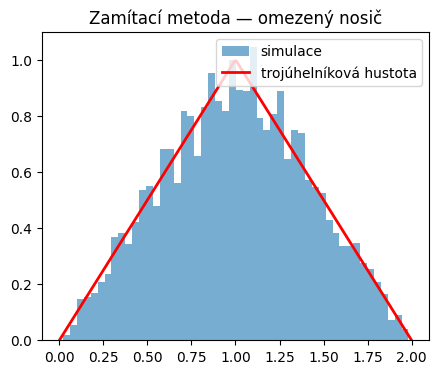

In [8]:
a, b = 0, 2

def f_triangular(x):
    # trojúhelníková hustota se špičkou v x=1, nulová mimo (0,2)
    return np.where((x >= 0) & (x <= 1), x,
           np.where((x > 1) & (x <= 2), 2 - x, 0.0))

M = 1.0  # maximum trojúhelníkové hustoty v x=1

def rejection_bounded(f, a, b, M, n, rng):
    accepted = []
    trials = 0
    while len(accepted) < n:
        u_i, v_i = rng.uniform(0, 1, 2)
        x_i = a + (b - a) * u_i
        trials += 1
        if v_i * M <= f(x_i):
            accepted.append(x_i)
    return np.array(accepted), trials

rng = np.random.default_rng(2)
sample_tri, trials = rejection_bounded(f_triangular, a, b, M, 5000, rng)
print(f"Míra přijetí ≈ {len(sample_tri)/trials:.2%}  (očekáváme obsah trojúhelníku / obsah obdélníku = 1/2 = 50%)")

xs2 = np.linspace(a, b, 200)
plt.hist(sample_tri, bins=50, density=True, alpha=0.6, label="simulace")
plt.plot(xs2, f_triangular(xs2), 'r-', lw=2, label="trojúhelníková hustota")
plt.legend()
plt.title("Zamítací metoda — omezený nosič")
plt.show()


## 5. Generování náhodných vektorů pomocí inverzní metody

Postup pro dvourozměrnou veličinu $(X,Y)$ s marginální $F(x)$ a podmíněnou
$F(y\mid x)$:
1. vygeneruj $u_i, v_i$ nezávisle z $R(0,1)$
2. $x_i = F^{-1}(u_i)$
3. $y_i = F^{-1}(v_i \mid x_i)$

Příklad: $X\sim Exp(1)$ a $Y\mid X=x \sim Exp(\beta+x)$ (podobná struktura
jako u Arnold–Straussova rozdělení z minulé přednášky).

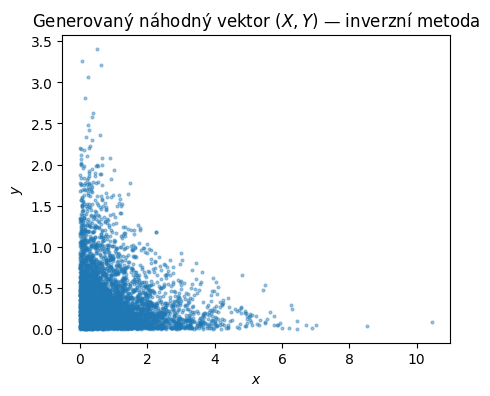

E(X) odhad = 1.000 (teoreticky 1.0)


In [9]:
beta = 2.0

def generate_vector_inverse(n, rng, beta=beta):
    u = rng.uniform(0, 1, n)
    x = -np.log(1 - u)                    # X ~ Exp(1), F^{-1}(u) = -ln(1-u)
    v = rng.uniform(0, 1, n)
    rate_y = beta + x                     # Y|X=x ~ Exp(beta + x)
    y = -np.log(1 - v) / rate_y
    return x, y

rng = np.random.default_rng(3)
X, Y = generate_vector_inverse(5000, rng)

plt.scatter(X, Y, s=4, alpha=0.4)
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.title("Generovaný náhodný vektor $(X,Y)$ — inverzní metoda")
plt.show()

print(f"E(X) odhad = {X.mean():.3f} (teoreticky 1.0)")


## 6. Generování náhodných vektorů pomocí zamítací metody

Pro hustotu $f(x,y)$ nenulovou na omezené oblasti $A$ a $M=\max_{(x,y)\in A} f(x,y)$:
1. vygeneruj trojici $x_i,y_i,w_i$ rovnoměrně z plochy $A$ a výšky $M$
2. přijmi $(x_i,y_i)$, pokud $w_i \leq f(x_i,y_i)$

Použijeme dvourozměrnou hustotu $f(x,y)=\dfrac{6}{5}(x+y^2)$ na $(0,1)\times(0,1)$
(klasický cvičný příklad se sdruženou hustotou).

Míra přijetí ≈ 42.02%


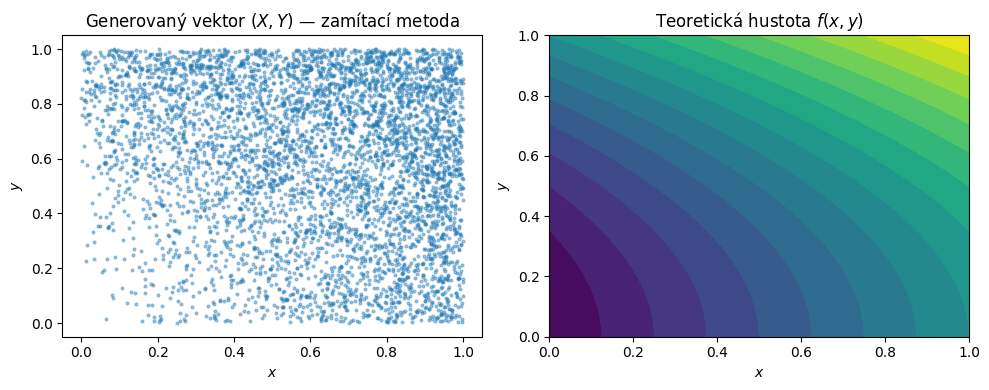

In [10]:
def f_joint(x, y):
    return 6/5 * (x + y**2)

A_x, A_y = (0, 1), (0, 1)
M = f_joint(1, 1)  # maximum na (0,1)x(0,1) je v rohu (1,1)

def rejection_vector(f, xr, yr, M, n, rng):
    accepted = []
    trials = 0
    while len(accepted) < n:
        x_i = rng.uniform(*xr)
        y_i = rng.uniform(*yr)
        w_i = rng.uniform(0, M)
        trials += 1
        if w_i <= f(x_i, y_i):
            accepted.append((x_i, y_i))
    return np.array(accepted), trials

rng = np.random.default_rng(4)
sample_vec, trials = rejection_vector(f_joint, A_x, A_y, M, 5000, rng)
print(f"Míra přijetí ≈ {len(sample_vec)/trials:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(sample_vec[:, 0], sample_vec[:, 1], s=4, alpha=0.4)
axes[0].set_title("Generovaný vektor $(X,Y)$ — zamítací metoda")
axes[0].set_xlabel("$x$"); axes[0].set_ylabel("$y$")

xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
axes[1].contourf(xx, yy, f_joint(xx, yy), levels=20, cmap="viridis")
axes[1].set_title("Teoretická hustota $f(x,y)$")
axes[1].set_xlabel("$x$"); axes[1].set_ylabel("$y$")
plt.tight_layout()
plt.show()


### Ověření: marginální $E(X)$ a $E(Y)$ ze simulace vs. teorie

Pro $f(x,y)=\frac{6}{5}(x+y^2)$ na jednotkovém čtverci lze spočítat
$E X = \int_0^1\!\int_0^1 x\cdot\frac{6}{5}(x+y^2)\,dx\,dy$ apod. —
zkusíme to numericky přímo z definice a porovnáme se simulací.

In [11]:
import sympy as sp

x, y = sp.symbols('x y', positive=True)
f_sym = sp.Rational(6, 5) * (x + y**2)

EX_theory = sp.integrate(sp.integrate(x * f_sym, (x, 0, 1)), (y, 0, 1))
EY_theory = sp.integrate(sp.integrate(y * f_sym, (x, 0, 1)), (y, 0, 1))

print(f"E(X) teoreticky = {EX_theory} = {float(EX_theory):.4f}, simulačně = {sample_vec[:,0].mean():.4f}")
print(f"E(Y) teoreticky = {EY_theory} = {float(EY_theory):.4f}, simulačně = {sample_vec[:,1].mean():.4f}")


E(X) teoreticky = 3/5 = 0.6000, simulačně = 0.6057
E(Y) teoreticky = 3/5 = 0.6000, simulačně = 0.5956


## Shrnutí

| Metoda | Kdy použít | Co potřebujeme znát |
|---|---|---|
| LCG / rekurzivní / kombinovaný generátor | základ všech simulací | vhodné parametry $a,c,m$ |
| Inverzní transformace | umíme explicitně $F^{-1}$ | distribuční funkci a její inverzi |
| Zamítací metoda (obecná) | neumíme $F^{-1}$, ale umíme $f$ | dominující hustotu $g$ a konstantu $c$ |
| Zamítací metoda (omezený nosič) | $f$ nenulová jen na $(a,b)$ | maximum $M$ hustoty |
| Generování vektorů — inverzní | umíme marginální i podmíněnou $F^{-1}$ | obě inverzní distribuční funkce |
| Generování vektorů — zamítací | $f(x,y)$ nenulová na omezené oblasti $A$ | maximum $M$ na $A$ |
